<a href="https://colab.research.google.com/github/SSNEGI05/portfolio_analysis/blob/main/Portfolio_Optimization_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Modern Portfolio Theory & Optimization Engine


## Portfolio Return & Risk (The Free Lunch)

### The Concept
When you combine assets into a portfolio, the **Return** is simply the weighted average of the individual returns. However, the **Risk (Variance)** is NOT the weighted average. Because assets do not move in perfect sync (Correlation < 1), combining them actually *cancels out* some of the risk. Harry Markowitz called this the "only free lunch in finance."

### The Mathematics
* **Portfolio Return:** $E(R_p) = w_A E(R_A) + w_B E(R_B)$
* **Portfolio Variance:** $\sigma_p^2 = w_A^2 \sigma_A^2 + w_B^2 \sigma_B^2 + 2w_A w_B \text{Cov}(A,B)$

The third term ($2w_A w_B \text{Cov}(A,B)$) is the diversification engine. If the covariance is low or negative, it subtracts total risk from the portfolio.

In [2]:
# ==============================================================================
# CELL 1: PROVING THE "FREE LUNCH" OF DIVERSIFICATION
# ==============================================================================

import yfinance as yf
import numpy as np
import pandas as pd

# --- Adjustable Parameters ---
# We use two stocks that behave differently to show diversification
asset_A = "RELIANCE.NS"
asset_B = "SUNPHARMA.NS"
start_date = "2020-01-01"
end_date = "2026-03-01"
weights = np.array([0.50, 0.50]) # 50% in A, 50% in B
trading_days = 252

print(f"Fetching data for {asset_A} and {asset_B}...")

# 1. Fetch Data & Calculate Returns
data = yf.download([asset_A, asset_B], start=start_date, end=end_date, auto_adjust=True)['Close']
returns = np.log(data / data.shift(1)).dropna()

# 2. Calculate Standalone Risk (Annualized Volatility)
# Standard deviation * square root of 252 trading days
risk_A = returns[asset_A].std() * np.sqrt(trading_days)
risk_B = returns[asset_B].std() * np.sqrt(trading_days)

# 3. Calculate Portfolio Risk using the Variance Formula
# Portfolio Variance = (wA^2 * VarA) + (wB^2 * VarB) + (2 * wA * wB * Cov(A,B))
cov_matrix = returns.cov() * trading_days
port_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
port_risk = np.sqrt(port_variance) # Volatility is the square root of variance

# 4. Display the Results
print("-" * 50)
print(f"--- The Diversification Benefit ---")
print(f"Standalone Risk ({asset_A}): {risk_A:.2%}")
print(f"Standalone Risk ({asset_B}): {risk_B:.2%}")
print("-" * 50)

# Calculate what the risk WOULD be without the "Free Lunch" (Simple Average)
naive_risk = (weights[0] * risk_A) + (weights[1] * risk_B)

print(f"Naive Average Risk (If no diversification existed): {naive_risk:.2%}")
print(f"Actual Portfolio Risk (50/50 split):              {port_risk:.2%}")
print(f"Risk Eliminated by Diversification:               {naive_risk - port_risk:.2%}")

[*********************100%***********************]  2 of 2 completed

Fetching data for RELIANCE.NS and SUNPHARMA.NS...
--------------------------------------------------
--- The Diversification Benefit ---
Standalone Risk (RELIANCE.NS): 28.09%
Standalone Risk (SUNPHARMA.NS): 24.60%
--------------------------------------------------
Naive Average Risk (If no diversification existed): 26.35%
Actual Portfolio Risk (50/50 split):              21.42%
Risk Eliminated by Diversification:               4.93%


# Efficient Frontier & Monte Carlo Simulation

### The Concept
If you have a universe of 5 stocks, there are infinite ways to assign percentage weights to them.
* The **Efficient Frontier** is the extreme top-left outer edge of all these possible combinations.
* It represents the absolute best possible return you can get for any specific level of risk. Any portfolio that sits *inside* the curve (below the frontier) is considered "inefficient" because you are taking on unnecessary risk for your level of return.

### The Problem & Solution
**The Problem:** We need to find the optimal boundary of portfolios, but checking every single weight combination from 0% to 100% for multiple stocks is mathematically exhausting.
**The Solution:** We use a "Brute-Force" **Monte Carlo Simulation**. We tell Python to generate 10,000 completely random portfolios, calculate the risk and return for each, and plot them. The top edge of the resulting "cloud" of dots will visually reveal the Efficient Frontier.

### Pros and Cons
* **Pros:** Highly visual and intuitive. It instantly shows the "danger zone" of inefficient portfolios and proves that diversification creates a distinct boundary.
* **Cons:** It is computationally heavy and only *approximates* the perfect boundary. To find the exact mathematical top, we need optimization algorithms (which we will build next).


[*******************   40%                       ]  2 of 5 completed

Fetching data to build the Efficient Frontier for: ['RELIANCE.NS', 'HDFCBANK.NS', 'TCS.NS', 'ITC.NS', 'SUNPHARMA.NS']...


[*********************100%***********************]  5 of 5 completed


Simulating 10000 random portfolios. This takes a few seconds...


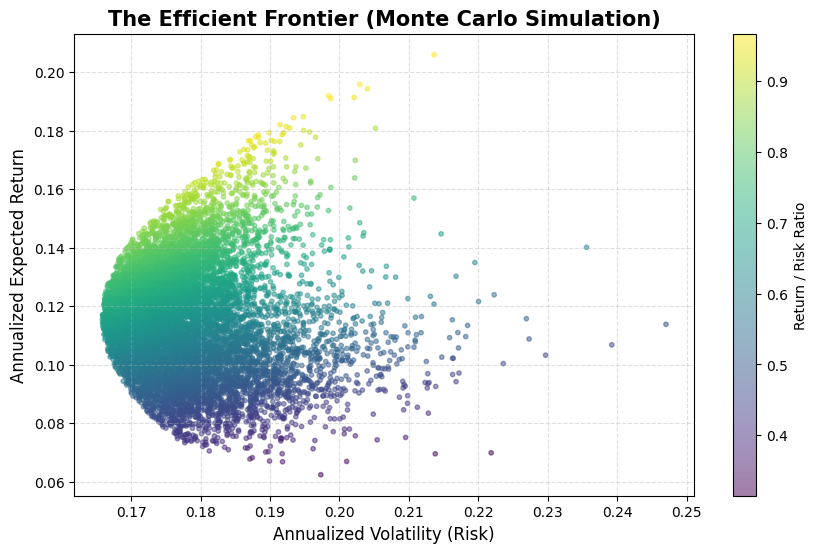

In [4]:
# ==============================================================================
# CELL 2: THE EFFICIENT FRONTIER (MONTE CARLO SIMULATION)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
# --- Adjustable Parameters ---
num_portfolios = 10000  # Number of random guesses to make
tickers = ["RELIANCE.NS", "HDFCBANK.NS", "TCS.NS", "ITC.NS", "SUNPHARMA.NS"]
start_date = "2020-01-01"
end_date = "2026-03-01"
trading_days = 252

print(f"Fetching data to build the Efficient Frontier for: {tickers}...")
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']
returns = np.log(data / data.shift(1)).dropna()

# 1. Calculate the core metrics
mean_returns = returns.mean() * trading_days
cov_matrix = returns.cov() * trading_days

# 2. Set up empty arrays to hold our simulation results
p_ret = []
p_vol = []
p_weights = []

print(f"Simulating {num_portfolios} random portfolios. This takes a few seconds...")

# 3. The Monte Carlo Engine
for _ in range(num_portfolios):
    # Generate random weights and force them to equal 1.0 (100%)
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    # Calculate expected return and volatility (risk)
    ret = np.sum(weights * mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Store the data
    p_ret.append(ret)
    p_vol.append(vol)
    p_weights.append(weights)

# Convert lists to NumPy arrays for fast plotting
p_ret = np.array(p_ret)
p_vol = np.array(p_vol)

# 4. Plotting the 'Cloud'
plt.figure(figsize=(10, 6))
# We color the dots by their Return-to-Risk ratio
plt.scatter(p_vol, p_ret, c=p_ret/p_vol, marker='o', cmap='viridis', s=10, alpha=0.5)
plt.colorbar(label='Return / Risk Ratio')

plt.title('The Efficient Frontier (Monte Carlo Simulation)', fontsize=15, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Expected Return', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Mathematical Optimization: Finding the Exact Portfolios

### The Concept
Instead of randomly guessing weights, we use calculus-based optimization algorithms to find the exact points on the Efficient Frontier.
* **Minimum Variance Portfolio:** The absolute safest portfolio mathematically possible. It sits at the extreme left tip of the frontier. The algorithm ignores returns entirely and focuses solely on minimizing overlapping volatility.
* **Maximum Sharpe Ratio Portfolio:** The "Holy Grail" of investing. It provides the highest excess return per unit of risk. It is found by drawing a tangent line from the Risk-Free Rate to the edge of the frontier.

### The Problem & Solution
**The Problem:** The Monte Carlo scatter plot shows us the boundary visually, but it doesn't give us the precise percentage weights required to actually execute the trades in our brokerage account.
**The Solution:** We will use the `scipy.optimize` library. We give Python a mathematical command: "Find the exact weights that minimize volatility" (for MVP) and "Find the exact weights that maximize the Sharpe ratio" (for MSR).

### Pros and Cons
* **Pros:** Delivers exact, actionable numbers (weights, expected return, and risk). It removes all guesswork and mathematically guarantees the best outcome based on historical data.
* **Cons:** Pure mathematical optimizers can be "greedy." Without constraints, they might suggest putting 0% in three stocks and 100% in one just to get a 0.01 higher Sharpe ratio.

Running optimization algorithms to find exact weights...

🎯 MAXIMUM SHARPE RATIO PORTFOLIO (Best Return per Risk)
Expected Annual Return: 23.99%
Annual Volatility:      24.60%
Sharpe Ratio:           0.7108

Optimal Weights:
 - RELIANCE.NS: 0.00%
 - HDFCBANK.NS: 0.00%
 - TCS.NS: 0.00%
 - ITC.NS: 100.00%
 - SUNPHARMA.NS: 0.00%

🛡️ MINIMUM VARIANCE PORTFOLIO (Safest Possible)
Expected Annual Return: 11.64%
Annual Volatility:      16.58%
Sharpe Ratio:           0.3099

Optimal Weights:
 - RELIANCE.NS: 18.97%
 - HDFCBANK.NS: 24.29%
 - TCS.NS: 5.05%
 - ITC.NS: 24.68%
 - SUNPHARMA.NS: 27.01%


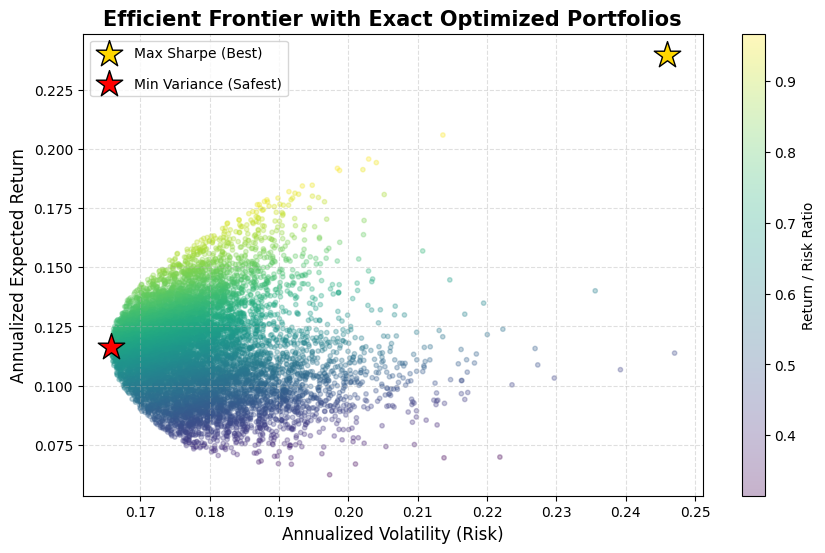

In [5]:
# ==============================================================================
# CELL 3: FINDING THE EXACT NUMBERS (OPTIMIZATION)
# ==============================================================================

import scipy.optimize as sco
import pandas as pd

# --- Adjustable Parameters ---
risk_free_rate = 0.065  # RBI Repo Rate (~6.5%)

print("Running optimization algorithms to find exact weights...")

# 1. Define the mathematical formulas for the optimizer
def calc_portfolio_perf(weights, mean_returns, cov_matrix, risk_free_rate):
    port_ret = np.sum(mean_returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_ret - risk_free_rate) / port_vol
    return port_ret, port_vol, sharpe

# Python optimizers can only *minimize*.
# To maximize Sharpe, we tell it to minimize the *negative* Sharpe.
def neg_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    return -calc_portfolio_perf(weights, mean_returns, cov_matrix, risk_free_rate)[2]

def get_vol(weights, mean_returns, cov_matrix, risk_free_rate):
    return calc_portfolio_perf(weights, mean_returns, cov_matrix, risk_free_rate)[1]

# 2. Setup the Rules (Constraints) for the Optimizer
num_assets = len(tickers)
args = (mean_returns, cov_matrix, risk_free_rate)
# Rule 1: All weights must add up to exactly 1.0 (100%)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
# Rule 2: Long-Only (No shorting). Weights must be between 0 and 1.
bounds = tuple((0.0, 1.0) for asset in range(num_assets))
# Starting guess (Equal weight)
initial_guess = num_assets * [1. / num_assets,]

# ------------------------------------------------------------------------------
# 3. EXECUTE THE OPTIMIZATIONS
# ------------------------------------------------------------------------------
# A. Find Maximum Sharpe Portfolio
opt_sharpe = sco.minimize(neg_sharpe, initial_guess, args=args, method='SLSQP', bounds=bounds, constraints=constraints)
msr_weights = opt_sharpe.x
msr_ret, msr_vol, msr_sharpe = calc_portfolio_perf(msr_weights, mean_returns, cov_matrix, risk_free_rate)

# B. Find Minimum Variance Portfolio
opt_var = sco.minimize(get_vol, initial_guess, args=args, method='SLSQP', bounds=bounds, constraints=constraints)
mvp_weights = opt_var.x
mvp_ret, mvp_vol, mvp_sharpe = calc_portfolio_perf(mvp_weights, mean_returns, cov_matrix, risk_free_rate)

# 4. Display the Exact Numbers
print("\n" + "="*50)
print("🎯 MAXIMUM SHARPE RATIO PORTFOLIO (Best Return per Risk)")
print("="*50)
print(f"Expected Annual Return: {msr_ret:.2%}")
print(f"Annual Volatility:      {msr_vol:.2%}")
print(f"Sharpe Ratio:           {msr_sharpe:.4f}")
print("\nOptimal Weights:")
for ticker, weight in zip(tickers, msr_weights):
    print(f" - {ticker}: {weight:.2%}")

print("\n" + "="*50)
print("🛡️ MINIMUM VARIANCE PORTFOLIO (Safest Possible)")
print("="*50)
print(f"Expected Annual Return: {mvp_ret:.2%}")
print(f"Annual Volatility:      {mvp_vol:.2%}")
print(f"Sharpe Ratio:           {mvp_sharpe:.4f}")
print("\nOptimal Weights:")
for ticker, weight in zip(tickers, mvp_weights):
    print(f" - {ticker}: {weight:.2%}")

# 5. Plot the exact points on our Monte Carlo Cloud
plt.figure(figsize=(10, 6))
plt.scatter(p_vol, p_ret, c=p_ret/p_vol, marker='o', cmap='viridis', s=10, alpha=0.3)
plt.colorbar(label='Return / Risk Ratio')

# Plot the Stars
plt.scatter(msr_vol, msr_ret, marker='*', color='gold', s=400, edgecolor='black', label='Max Sharpe (Best)')
plt.scatter(mvp_vol, mvp_ret, marker='*', color='red', s=400, edgecolor='black', label='Min Variance (Safest)')

plt.title('Efficient Frontier with Exact Optimized Portfolios', fontsize=15, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Expected Return', fontsize=12)
plt.legend(labelspacing=1.2)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Real-World Constraints & Compliance

### The Concept
Pure mathematical optimizers are "greedy." They exploit historical data to the absolute maximum. If one stock had an unusually smooth uptrend last year, the optimizer might allocate 80% of your capital to it. In the real world, regulators (like SEBI) and risk managers enforce **Concentration Limits** to ensure true diversification.

### The Problem & Solution
**The Problem:** An unconstrained Maximum Sharpe Ratio (MSR) portfolio is often dangerously concentrated in just 1 or 2 assets, exposing the investor to massive single-company risk.
**The Solution:** We introduce **Bounds and Constraints** into our Python optimizer. For example, we can force the algorithm to hold a maximum of 30% in any single stock.



### Pros and Cons
* **Pros:** Prevents catastrophic blowups if the historical "star" stock suddenly crashes. Creates a realistic, investable, and compliant portfolio.
* **Cons:** It lowers your theoretical Sharpe Ratio and Expected Return. This slight drop in performance is the "cost of compliance" and safety.

Applying strict maximum weight limit of 30.0% per asset...

⚖️ CONSTRAINED vs. UNCONSTRAINED MSR PORTFOLIO
Unconstrained Sharpe: 0.7108 (Pure Math)
Constrained Sharpe:   0.4300 (Real World)
Cost of Compliance:   0.2808 drop in Sharpe Ratio


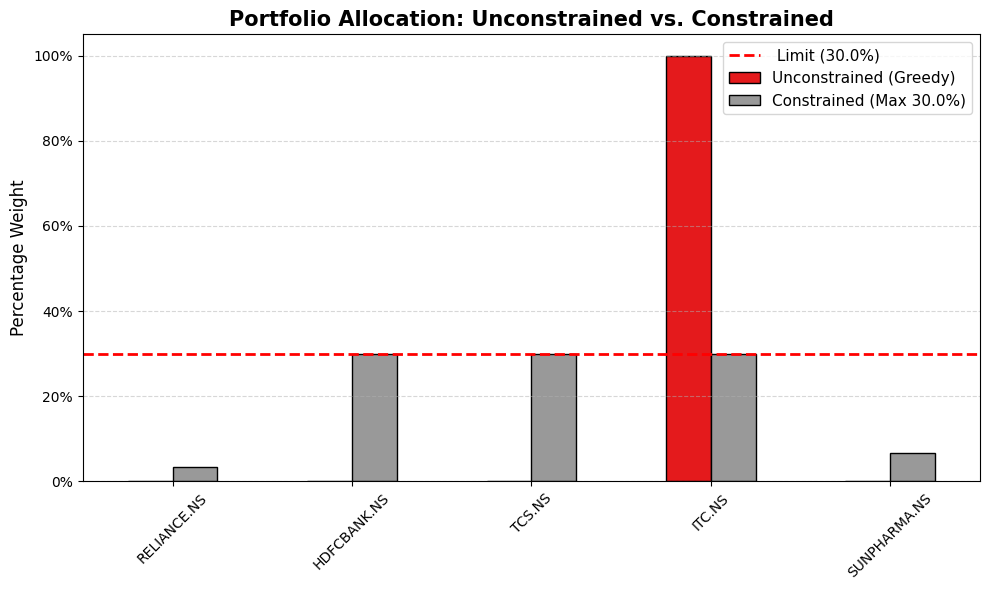

In [11]:
# ==============================================================================
# CELL 4: APPLYING REAL-WORLD CONSTRAINTS
# ==============================================================================

from matplotlib.ticker import PercentFormatter

# --- Adjustable Parameters ---
max_weight_limit = 0.30  # No single stock can exceed 30% of the portfolio
risk_free_rate = 0.065

print(f"Applying strict maximum weight limit of {max_weight_limit*100}% per asset...")

# 1. Setup the NEW Rules (Constrained Bounds)
num_assets = len(tickers)
args = (mean_returns, cov_matrix, risk_free_rate)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# NEW BOUNDS: Min 0.0 (Long only), Max 0.30 (30% Limit)
strict_bounds = tuple((0.0, max_weight_limit) for asset in range(num_assets))
initial_guess = num_assets * [1. / num_assets,]

# 2. Re-run the MSR Optimization with the strict bounds
opt_constrained = sco.minimize(neg_sharpe, initial_guess, args=args,
                               method='SLSQP', bounds=strict_bounds, constraints=constraints)

constrained_weights = opt_constrained.x
con_ret, con_vol, con_sharpe = calc_portfolio_perf(constrained_weights, mean_returns, cov_matrix, risk_free_rate)

# 3. Compare the Results
print("\n" + "="*50)
print("⚖️ CONSTRAINED vs. UNCONSTRAINED MSR PORTFOLIO")
print("="*50)
print(f"Unconstrained Sharpe: {msr_sharpe:.4f} (Pure Math)")
print(f"Constrained Sharpe:   {con_sharpe:.4f} (Real World)")
print(f"Cost of Compliance:   {(msr_sharpe - con_sharpe):.4f} drop in Sharpe Ratio")

# 4. Visualizing the Difference (Bar Chart)
# Create a DataFrame for easy plotting
weight_df = pd.DataFrame({
    'Unconstrained (Greedy)': msr_weights,
    f'Constrained (Max {max_weight_limit*100}%)': constrained_weights
}, index=tickers)

# Plotting
ax = weight_df.plot(kind='bar', figsize=(10, 6), colormap='Set1', edgecolor='black')
plt.title('Portfolio Allocation: Unconstrained vs. Constrained', fontsize=15, fontweight='bold')
plt.ylabel('Percentage Weight', fontsize=12)
plt.axhline(max_weight_limit, color='red', linestyle='--', linewidth=2, label=f' Limit ({max_weight_limit*100}%)')

# Clean, warning-free percentage formatting
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Covariance Matrix Estimation & Noise Reduction

### The Concept
To optimize a portfolio, the algorithm needs to know exactly how every stock moves relative to the others (the Covariance Matrix). Standard Python functions calculate **Sample Covariance**, which assumes historical data is 100% accurate.
However, financial markets are full of "Statistical Noise"—random, temporary correlations that don't mean anything. Because optimizers are mathematically "greedy," they act as **Error Maximizers**, betting your entire portfolio on these fake correlations.

### The Problem & Solution
**The Problem:** Feeding raw, noisy data into an optimizer creates a fragile portfolio that looks great in a backtest but blows up in the live market.
**The Solution:** We use **Ledoit-Wolf Shrinkage**. This algorithm acts like a filter. It takes the highly erratic, noisy real-world data ($S$) and mathematically "shrinks" it toward a highly structured, stable baseline ($F$) using an intensity factor ($\delta$).
The formula is: $\Sigma_{\text{shrink}} = \delta F + (1-\delta) S$

### Pros and Cons
* **Pros:** Creates an institutional-quality portfolio that survives real-world market shocks. It naturally prevents extreme, concentrated bets without needing hard limits.
* **Cons:** It assumes that the underlying relationships between stocks are relatively stable. If there is a massive, sudden structural change in the economy (like a new pandemic), the shrunk matrix might be slightly slow to react.

Building the Final Institutional Portfolio...
Applying Ledoit-Wolf Shrinkage AND a 30.0% Maximum Weight Limit...

🏆 THE FINAL INSTITUTIONAL PORTFOLIO WEIGHTS


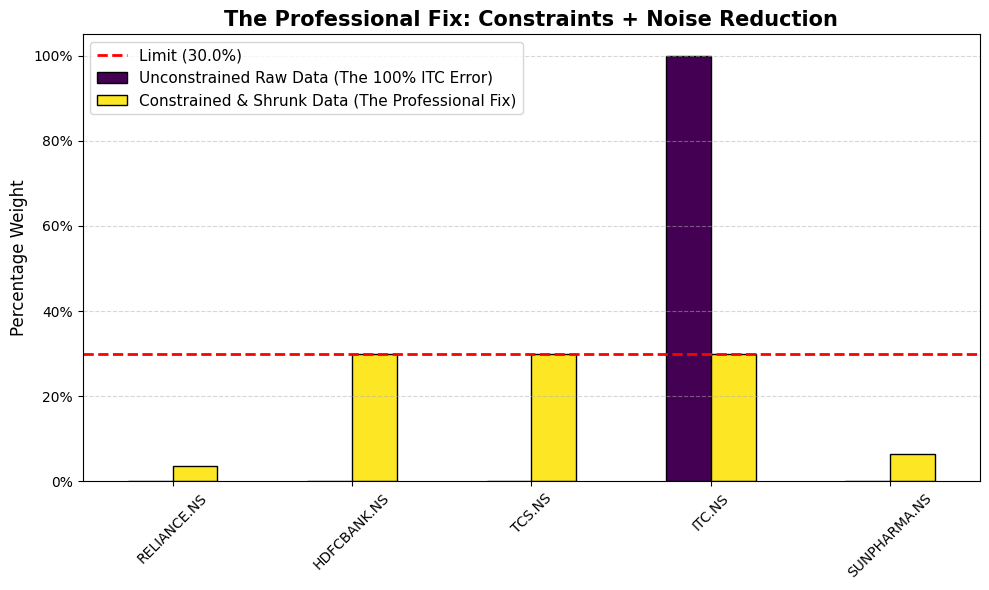


Final Portfolio Stats (Realistic Expectations):
Expected Return: 14.31%
Volatility:      17.93%
Sharpe Ratio:    0.4355


In [16]:
# ==============================================================================
# CELL 5: THE ULTIMATE INSTITUTIONAL PORTFOLIO (SHRINKAGE + CONSTRAINTS)
# ==============================================================================

from sklearn.covariance import LedoitWolf
from matplotlib.ticker import PercentFormatter

print("Building the Final Institutional Portfolio...")
print(f"Applying Ledoit-Wolf Shrinkage AND a {max_weight_limit*100}% Maximum Weight Limit...")

# 1. Clean the Risk Data (Ledoit-Wolf)
lw = LedoitWolf().fit(returns)
shrunk_cov_matrix = lw.covariance_ * trading_days

# 2. Setup the Optimizer Rules
args_shrunk = (mean_returns, shrunk_cov_matrix, risk_free_rate)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# APPLY THE HANDCUFFS: Min 0.0, Max 0.30 (30% Limit)
strict_bounds = tuple((0.0, max_weight_limit) for asset in range(num_assets))

# 3. Run the Maximum Sharpe Optimization (With clean data AND strict rules)
opt_final = sco.minimize(neg_sharpe, initial_guess, args=args_shrunk,
                         method='SLSQP', bounds=strict_bounds, constraints=constraints)

final_weights = opt_final.x
final_ret, final_vol, final_sharpe = calc_portfolio_perf(final_weights, mean_returns, shrunk_cov_matrix, risk_free_rate)

# 4. Visualizing the Final Masterpiece
print("\n" + "="*50)
print("🏆 THE FINAL INSTITUTIONAL PORTFOLIO WEIGHTS")
print("="*50)

final_weight_df = pd.DataFrame({
    'Unconstrained Raw Data (The 100% ITC Error)': msr_weights,
    'Constrained & Shrunk Data (The Professional Fix)': final_weights
}, index=tickers)

ax = final_weight_df.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.title('The Professional Fix: Constraints + Noise Reduction', fontsize=15, fontweight='bold')
plt.ylabel('Percentage Weight', fontsize=12)

# Show the SEBI limit line
plt.axhline(max_weight_limit, color='red', linestyle='--', linewidth=2, label=f'Limit ({max_weight_limit*100}%)')

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print the final stats
print("\nFinal Portfolio Stats (Realistic Expectations):")
print(f"Expected Return: {final_ret:.2%}")
print(f"Volatility:      {final_vol:.2%}")
print(f"Sharpe Ratio:    {final_sharpe:.4f}")

# Final Verdict: The Reality of Portfolio Optimization

### The "Half-Solved" Problem
Ledoit-Wolf Shrinkage is a masterpiece for cleaning the **Risk (Covariance Matrix)**. It successfully filters out statistical noise and fake correlations. However, it is completely blind to the other half of the optimization equation: **Expected Returns**.

### The Danger of the "Greedy Robot"
If you run an *unconstrained* optimization looking for the Maximum Sharpe Ratio, the algorithm will aggressively chase historical returns. If one asset (like ITC) had a massive, lucky run-up over the given timeframe, the optimizer will ignore your perfectly cleaned risk matrix and dump 100% of the capital into that single asset. It falsely assumes the past anomaly is a permanent guarantee.



### The Institutional Conclusion
To build a portfolio that actually survives live market conditions, you cannot rely on raw optimization alone. You must build a system with two mandatory pillars:
1. **Clean the Risk:** Use Ledoit-Wolf Shrinkage to prevent the algorithm from making bets on fake, temporary correlations.
2. **Handcuff the Returns:** Apply strict mathematical weight constraints (e.g., Max 30% per asset) to prevent catastrophic concentration risk caused by return-chasing.

An unconstrained optimizer is just an error-maximizer. A constrained, noise-filtered optimizer is a professional quantitative engine.